# The TSMC lab — 21.6 years of the nearest regime

SK Hynix's ADR programme is fourteen sessions old. Every question the trade sheet has to
answer is a question about a **distribution** — how long an elevated premium takes to
resolve, which leg closes it, how far it goes against you first, whether hedging the
currency matters — and fourteen observations cannot describe one.

So this notebook measures the deepest pair in the same family and reports what actually
happened. **It is a characterisation, not a forecast**, and §1 exists to bound how far its
numbers may be carried.

**What this session changed about the data.** The comparator's ADR leg was sitting at a
2016 start on disk, not because the history did not exist but because the leg's provider
chain resolved to the listing venue first and that venue's API serves a rolling ten-year
window. The chain now prefers a provider that serves from 1997 — admitted only because it
agrees with the listing venue **bit-for-bit** over the whole 2,513-day overlap. After
excluding the stock-dividend era (§1.0a), the usable sample went from 2,328 sessions to
**5,064**.

In [1]:
%matplotlib inline
import sys, pathlib, numpy as np, pandas as pd
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
pd.set_option("display.width", 190); pd.set_option("display.max_columns", 40)
from pipeline.viz import theme, figures
from pipeline.lab import tsmc as LAB
from pipeline.hedging.ratios import HedgeLegs
theme.apply()

FRAME = LAB.legs()
PI = FRAME["pi"]
SAMPLE = {"first": str(PI.index[0].date()), "last": str(PI.index[-1].date()), "n_obs": len(PI)}
print(f"{SAMPLE['n_obs']:,} sessions, {SAMPLE['first']} to {SAMPLE['last']}")
print(LAB.rule_grid_note())

5,064 sessions, 2005-01-03 to 2026-07-24
Rule grid PROVISIONAL (author ratification pending). Every grid cell is reported, so ratifying a range changes which cells are quoted, not any number.


## 1. The structural audit — similarities justify the lab, differences bound it

Read the **"which way it cuts"** column before reading any number in this notebook. It is
the reason none of these figures is a prediction.

In [2]:
from IPython.display import Markdown
COLS = ["dimension", "TSMC", "SKHY", "which way it cuts", "source"]
# Hand-rendered rather than DataFrame.to_markdown(), which needs `tabulate`. One table is not
# worth a dependency, and the cells contain prose that a DataFrame repr would truncate.
rows = ["| " + " | ".join(COLS) + " |", "|" + "---|" * len(COLS)]
rows += ["| " + " | ".join(c.replace("|", "/") for c in r) + " |" for r in LAB.STRUCTURAL_ROWS]
Markdown("\n".join(rows))

| dimension | TSMC | SKHY | which way it cuts | source |
|---|---|---|---|---|
| Conversion regime | Revolving. Cancelled ADSs return to a re-issuable pool; the facility refills. | Discretionary. Issuance needs Company consent (F-6 Ex. 99(a) undertaking); cancellation is a holder right (17 CFR 239.36(a)). | DECISIVE, and against the lab. Two-sided arbitrage makes TSMC's premium mean-reverting; SKHY's is reflected with an open upper tail. | F-6 Ex. 99(a); 17 CFR 239.36(a); README section 2 |
| Ratio mechanics | 1 ADS = 5 common shares, fixed; stock dividends absorbed by distributing additional ADSs, ratio preserved. | 10 ADSs = 1 common share, fixed (424B4). | Neutral. Both are constant-ratio programmes, so pi is a clean price ratio in both, which is what makes them comparable at all. | TSMC depositary terms; SK Hynix 424B4; pipeline/ingest/registry.py |
| FX regime | TWD, managed float with a central bank that smooths the close. | KRW, free float with deeper offshore forwards. | Against comparability. A smoothed currency mechanically dampens the FX channel, so TSMC's FX sensitivity is a LOWER bound on the won's. | pipeline/panel/fx_conventions.py; repo |
| Foreign-ownership architecture | No issuer-level statutory ceiling on the ordinary shares in the sample period. | 20% controlling-shareholder floor under MRFTA holding-company rules, which constrains the float that can back an issuance, not the ADR itself. | Against the lab. SKHY has a structural constraint on the supply side that TSMC does not, so persistence should be HIGHER for SKHY. | MRFTA holding-company rules; docs/regime_taxonomy.md |
| Index weight / home concentration | Largest TAIEX constituent by a wide margin for most of the sample. | Second-largest KOSPI constituent. | Neutral to mildly against. Both are index-dominant, so both attract the same passive-flow channel; TSMC's dominance is greater. | repo (D2 index series); README section 2 |
| ADR share of global liquidity | Large and persistent: the ADR is a primary venue for the name, not a satellite. | New programme; the ADR is a satellite of a much larger local book. | OVERSTATES comparability. A deep ADR makes TSMC's premium easier to arbitrage and faster to close than a thin one, so the lab's convergence speeds are OPTIMISTIC for SKHY. | repo (D1/D6 volume); stated as a qualitative ordering, not a measured share |
| Listed-derivatives depth | Deep listed options and futures on both the local line and the ADR across the whole sample. | Local futures and options exist; the ADR has no established surface. | OVERSTATES comparability, and it is why the convexity overlay stays CONTINGENT on the hedge menu: the lab's own pair could hedge a tail the traded pair cannot. | repo; pipeline/hedging/sheets.py |
| LETF presence | None for most of the sample. | Single-stock 2x listings suspended 2026-07-16, deposit requirement accelerated to 2026-07-31; eligibility admits only two names. | OUT OF SCOPE for the lab. H3's channel is SKHY-new, so the lab is silent on it rather than reassuring about it. | KRX/FSC notices in the D7 event register |
| Short-sale regime | Taiwan has run continuous borrowing with intermittent restriction; the SBL programme operates across the sample. | Ban imposed 2023-11, fully lifted 2025-03-31; all listed stocks shortable. | Against the lab in one specific way: SKHY's short leg has a REGIME RISK that recurred within three years, and no TSMC episode is a precedent for it. | D7 event register; docs/data_sources.md |
| Cycle exposure | Foundry: capex-cycle levered, customer-concentrated. | Memory: sharper, more volatile amplitude on the same global cycle. | Against comparability on amplitude. Memory's cycle is more violent, so episode MAGNITUDES from foundry history understate what memory can produce. | qualitative; asserted as a sector ordering, not measured here |

### The asymmetry paragraph

This is the boundary. Every figure below inherits it.

In [3]:
print(LAB.ASYMMETRY)

The differences do not cancel, and they do not point in random directions. Read down the
"which way it cuts" column and almost every row leans the same way: TSMC's history should
UNDERSTATE how persistent an SKHY premium can be, and OVERSTATE how comparable the two
trades are on execution.

Understating persistence. TSMC's facility refills, so its premium is pushed from both
sides and mean-reverts. SKHY's issuance needs Company consent, so it is a reflected
process whose upper tail has no arbitrage bound. Add the MRFTA floor on the float that
could back an issuance, and SKHY has a supply-side constraint TSMC never had. Whatever
half-life and whatever resolution rate the lab measures, the reflected case should be
slower and less certain.

Overstating comparability. TSMC's ADR is a primary venue with deep listed derivatives;
SKHY's is a two-week-old satellite with no established option surface. Arbitrage that is
cheap and capacious in the lab is neither in the traded pair. And the TWD is

### 1.0a Why the sample starts in 2005, and what happens if it does not

TSMC paid annual stock dividends into the early 2000s. Both legs are **raw** closes and the
depositary ratio is a constant 5.0, so a stock dividend the two providers adjust
inconsistently accumulates into the *level*: the constructed premium averages −55% in 1997
and walks to roughly zero by 2005. That is a compounded share-count artefact, not a discount
anyone left on the table.

Eleven one-leg-only price jumps above 5σ are detectable, **all** of them between 1997-10-09
and 2002-07-25 and clustered in the June–August ex-dividend season; none occur in the
following 24 years. Using *adjusted* closes on both legs is worse, because the two legs'
cash-dividend adjustments differ.

The cause-based cut is therefore 2002-07-26. The registry uses the **more conservative**
2005-01-03, which additionally requires the level to be economically possible. A screen that
looks at the level deserves suspicion, so here is the headline number under both:

In [4]:
LAB.curation_sensitivity()

,sample,n_obs,first,n_entries,frac_beats_carry,median_net_pp,p95_mae_pp
0,registry (2005-01-03),5064,2005-01-03,822,0.418,-2.23,21.74
1,cause-based (2002-07-26),5649,2002-07-26,1160,0.363,-3.14,21.78


The wider sample is **worse**, not better. The exclusion is not flattering the result — which
is the only form of answer a curation objection can actually be given.

## 2. Episode census (G25) — how often, how big, how long, and which leg closes it

An episode is a peak-to-trough swing exceeding a threshold, found by a **forward-only
reversal walk**: a running extreme is carried until the premium retraces the threshold, which
confirms it. Nothing is smoothed and no window is centred, so an episode's endpoints are
knowable when they are dated.

Every cell of the rule grid is reported. `dropped_short` is the number of swings the
`min_days` filter removed — carried so the filter is visible rather than silent.

One thing the full grid exposes that a single cell would hide: **the episode count is not
monotone in the threshold.** At `min_days=5`, the 3pp rule reports *more* episodes (355) than
the 2pp rule (346). That is the two-part rule behaving correctly — a larger reversal threshold
produces fewer but longer swings, so a smaller share of them is dropped by the duration
filter. The raw swing count *is* monotone, and the test suite pins that instead.

In [5]:
LAB.census(frame=FRAME)

,min_move_pp,min_days,n_episodes,dropped_short,n_compression,n_widening,median_move_pp,median_days,max_move_pp,compression_via_adr_leg,compression_via_local_leg,compression_via_fx_leg
0,2.0,5,346,1158,189,157,4.27,6,18.19,0.513,0.471,0.016
1,2.0,10,72,1432,30,42,4.48,12,15.87,0.433,0.533,0.033
2,2.0,20,9,1495,2,7,3.79,23,9.34,0.000,1.000,0.000
3,3.0,5,355,606,188,167,5.30,8,23.52,0.527,0.452,0.021
4,3.0,10,133,828,66,67,5.63,14,15.87,0.515,0.470,0.015
5,3.0,20,35,926,13,22,5.62,27,13.00,0.308,0.692,0.000
6,5.0,5,216,187,117,99,7.84,12,23.52,0.547,0.427,0.026
7,5.0,10,137,266,71,66,7.97,20,21.22,0.563,0.437,0.000
8,5.0,20,71,332,35,36,8.11,31,21.22,0.543,0.457,0.000
9,8.0,5,85,49,47,38,11.87,25,24.52,0.553,0.426,0.021


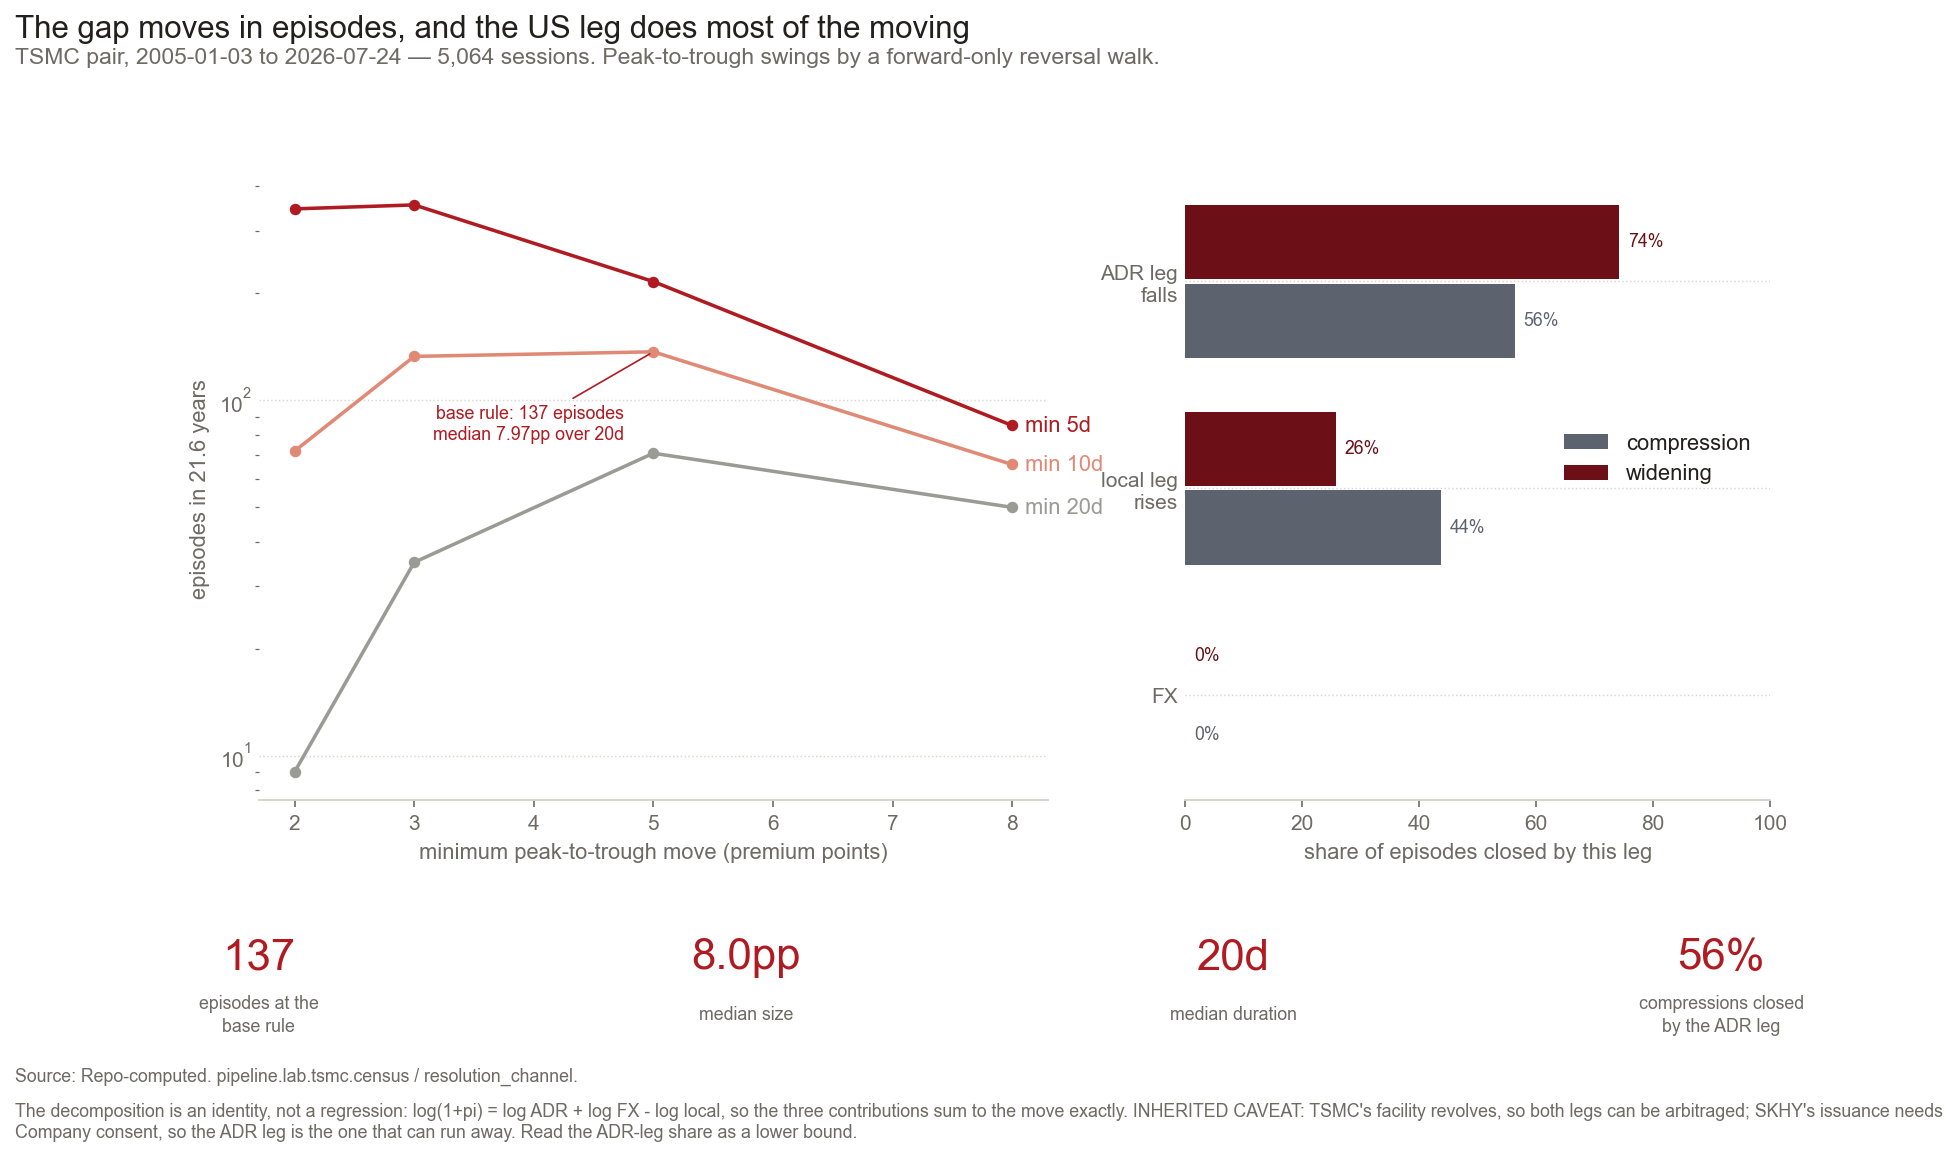

In [6]:
EP = LAB.episodes(PI, 5.0, 10)
CH = LAB.resolution_channel(FRAME, EP)
fig, meta = figures.g25_episode_census(LAB.census(frame=FRAME), EP, CH, SAMPLE)
fig;

**In plain terms**

- Over 21 years, the Taiwan Semiconductor version of this same gap opened and closed 137 times —
  so this is a recurring event, not a one-off.
- A typical episode was about 8 points wide and took 20 trading days to play out.
- When the gap closed, it usually closed because the US share came down, not because the local
  share went up. That tells you which leg to trade.

**Why the channel split is a trade decision, not trivia.** The decomposition is an identity —
`log(1+π) = log ADR + log FX − log local`, so the three contributions sum to the move exactly
(the notebook asserts the residual is zero). Compressions closed via the **ADR leg 56% of the
time** and via the local leg 44%; widenings ran through the ADR leg **74%** of the time.

The ADR is where both the convergence and the risk live. That promotes the short-ADR
expression on the sheet and demotes any framing in which the local leg does the work.

In [7]:
CH.groupby(["direction", "channel"]).agg(n=("move_pp","size"), median_move=("move_pp","median"), median_days=("days","median"))

n  median_move  median_days
direction   channel                                
compression adr_leg    40         8.61         19.0
            local_leg  31         7.36         23.0
widening    adr_leg    49         8.11         21.0
            local_leg  17         7.74         15.0

## 3. Entry outcomes against the breakeven (G26) — the lab's headline

The rule: enter short-premium whenever the premium sits above a given percentile **of its own
past** (expanding, 504-session warmup — the rule never sees its own future), hold for a fixed
horizon, subtract the bracketed carry.

Every (percentile × horizon × bracket) cell is reported.

In [8]:
EO = LAB.entry_outcomes(PI); EO[EO.horizon_d == 252]

,entry_pctile,horizon_d,bracket,n_entries,carry_cost_pp,median_net_pp,q25_net_pp,q75_net_pp,p05_net_pp,p95_net_pp,frac_beats_carry,median_rom,median_mae_pp,p95_mae_pp
6,0.80,252,low,1344,2.57,0.33,-7.07,5.65,-14.18,12.63,0.513,0.016,10.72,22.55
7,0.80,252,mid,1344,6.07,-3.17,-10.57,2.15,-17.68,9.13,0.348,-0.159,10.72,22.55
8,0.80,252,high,1344,12.07,-9.17,-16.57,-3.85,-23.68,3.13,0.108,-0.459,10.72,22.55
18,0.90,252,low,822,2.57,1.27,-5.52,7.17,-12.78,14.03,0.555,0.063,11.16,21.74
19,0.90,252,mid,822,6.07,-2.23,-9.02,3.67,-16.28,10.53,0.418,-0.112,11.16,21.74
20,0.90,252,high,822,12.07,-8.23,-15.02,-2.33,-22.28,4.53,0.164,-0.412,11.16,21.74
30,0.95,252,low,439,2.57,2.00,-5.50,7.69,-10.88,15.91,0.590,0.100,11.90,21.52
31,0.95,252,mid,439,6.07,-1.50,-9.00,4.19,-14.38,12.41,0.442,-0.075,11.90,21.52
32,0.95,252,high,439,12.07,-7.50,-15.00,-1.81,-20.38,6.41,0.191,-0.375,11.90,21.52
42,0.99,252,low,111,2.57,5.46,1.03,10.92,-6.78,18.02,0.784,0.273,9.30,21.47


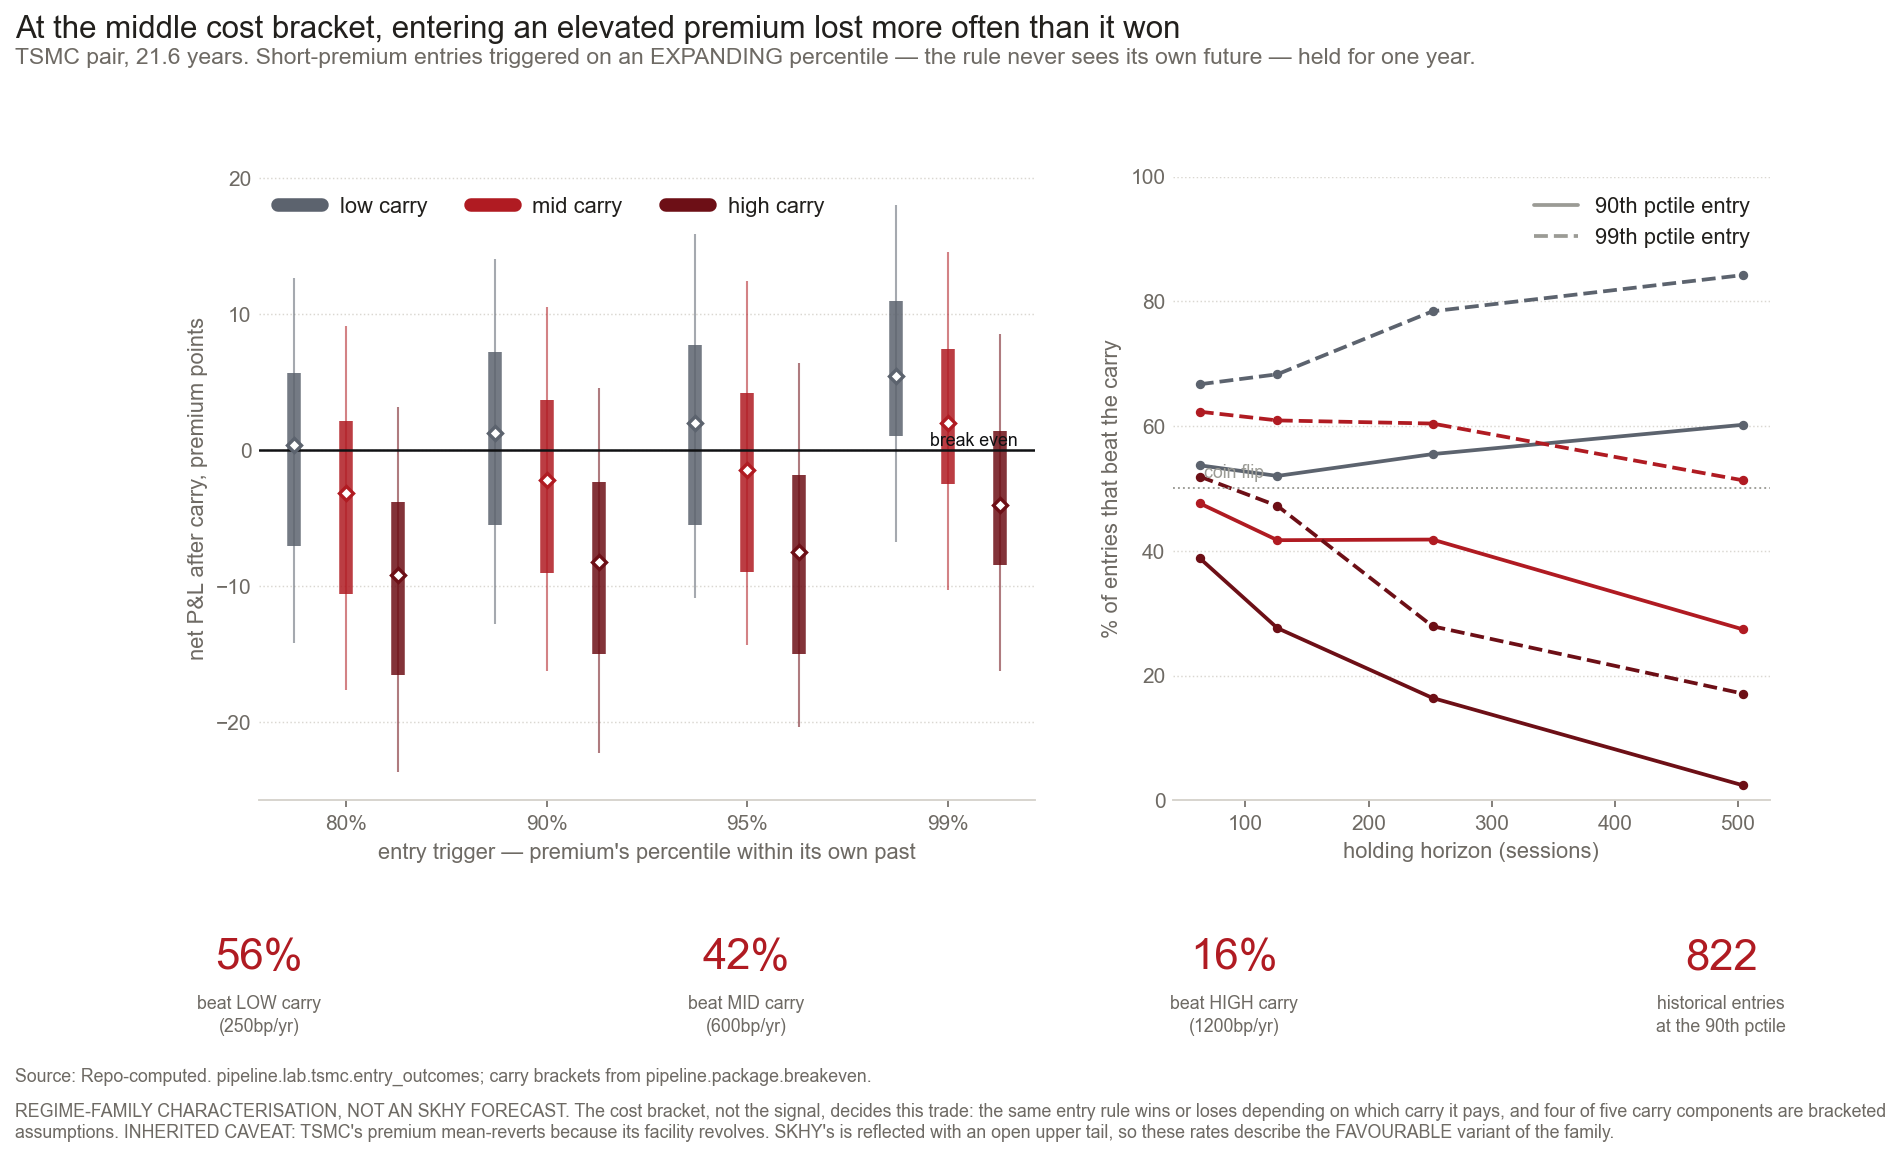

In [9]:
fig, meta = figures.g26_entry_outcomes(EO)
fig;

**In plain terms**

- We asked the obvious question of history: if you had sold this gap every time it was unusually
  wide, would you have made money after paying the costs?
- At the low cost estimate, just over half the time. At the middle estimate, only 42% of the time.
  At the high estimate, 16%.
- So the trade is decided by what it costs to hold, not by how clever the timing is — which is
  exactly why the financing conversation matters more than the forecast.

**The number the financing decision turns on.** At the 90th-percentile entry held one year:
**55.5%** of historical entries beat the *low* carry bracket, **41.8%** beat the *mid*, and
**16.4%** beat the *high*.

Two readings, and the second is the important one.

1. The signal is real and monotone in extremity — the 99th percentile beats mid carry 60.4%
   of the time against 34.8% at the 80th. Entering further out is better.
2. **The cost bracket, not the signal, decides the trade.** The same rule wins or loses
   depending only on which carry it pays, and four of the five carry components are still
   bracketed assumptions. That is a quantitative argument for having the desk conversation
   before having the view — and it is the empirical form of what the pitch already sells:
   access and financing, not timing.

And the boundary: this pair's facility **revolves**. These rates describe the mean-reverting,
*favourable* variant of the family.

## 4. What it costs you en route (G26b) — the case for sizing over stopping

Same entries, but now the *path*: the maximum adverse excursion before resolution. For a
short-premium position, adverse means the gap **widening**.

In [10]:
EX = LAB.excursions(PI)
SK = LAB.skhy_week_one_excursion()
print(f"excursion: median {EX.attrs['median_mae_pp']:.1f}pp   95th {EX.attrs['p95_mae_pp']:.1f}pp   "
      f"worst in 21.6 years {EX.attrs['max_mae_pp']:.1f}pp")
print(f"SKHY realised, first {SK['sessions']} sessions: {SK['excursion_pp']:.1f}pp")
EX

excursion: median 11.2pp   95th 21.7pp   worst in 21.6 years 25.3pp
SKHY realised, first 3 sessions: 35.6pp


,stop_pp,n_entries,frac_stopped,frac_stopped_but_would_have_won
0,2.0,822,0.945,0.597
1,4.0,822,0.860,0.512
2,6.0,822,0.738,0.394
3,8.0,822,0.672,0.330
4,10.0,822,0.544,0.220
5,15.0,822,0.297,0.099
6,20.0,822,0.080,0.018
7,30.0,822,0.000,0.000


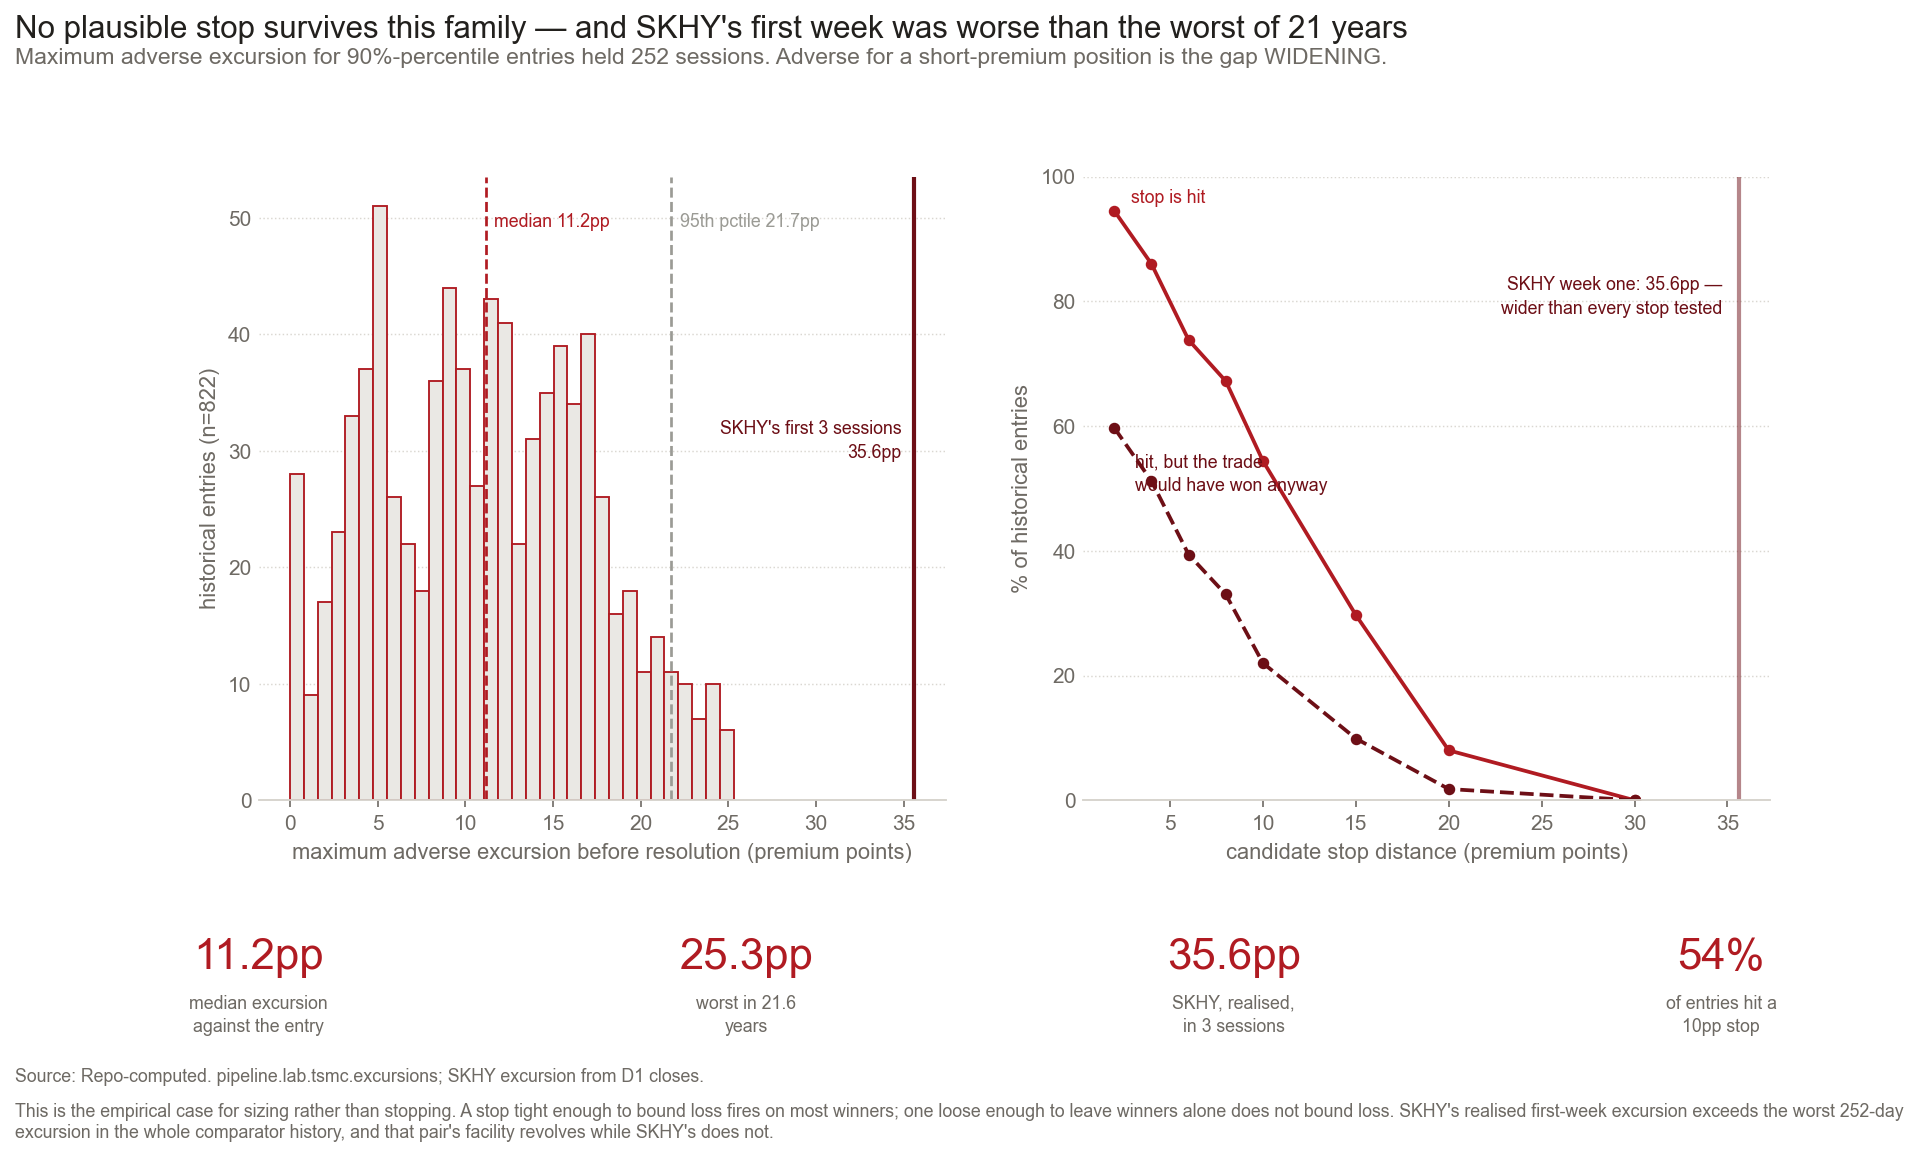

In [11]:
fig, meta = figures.g26b_stop_survival(EX, SK)
fig;

**In plain terms**

- Before these trades worked out, they went against you first — typically by 11 points, and in the
  worst case by 25.
- Hynix's gap moved 36 points against an early seller in three days. That is worse than the worst
  full year in two decades of the comparison pair.
- A stop-loss cannot fix this: set it tight and it fires on trades that would have won; set it
  loose and it does not protect you. Position size does the work instead.

**The finding that hardens the risk budget.** The worst 252-day adverse excursion in 21.6
years of the comparator is **25.3 points**. SKHY moved **35.6 points** against an early
seller in **three sessions** — larger than the worst case in the whole comparator history,
in a pair whose barrier is *harder* than the comparator's.

And the stop table shows why a stop is not the answer. A 10-point stop fires on **54%** of
historical entries, and on 22% of entries that would have ended profitable. Tighten it to 4
points and it fires on 86%. There is no distance at which it bounds loss without also
cutting the winners: this is the empirical case for **sizing** as the risk control, with
stops expressing intent. It is the same conclusion G24 reaches from the exit tree, reached
independently from the path distribution.

## 5. The FX case (G27)

The analytic sensitivity is `d(π)/d(FX) = (1+π)/FX`, a ceteris-paribus derivative. The
empirical one absorbs both equity legs' own FX betas, and is what a hedge actually faces.

In [12]:
FX = LAB.fx_sensitivity_deep(FRAME); FX

,era,n,mean_pi_pp,analytic_coef,empirical_coef,ci95_lo,ci95_hi,pp_per_1pct_fx,r2,theory_inside_ci
0,full sample,5063,6.24,1.062,0.856,0.653,1.058,0.856,0.0134,False
1,2005-2009 pre-GFC,1186,5.23,1.052,0.934,0.490,1.378,0.934,0.0142,True
2,2010-2015,1419,2.94,1.029,0.766,0.467,1.064,0.766,0.0176,True
3,2016-2020,1163,4.37,1.044,0.307,-0.066,0.680,0.307,0.0022,False
4,2021-2026,1295,12.47,1.125,1.262,0.792,1.732,1.262,0.0210,True


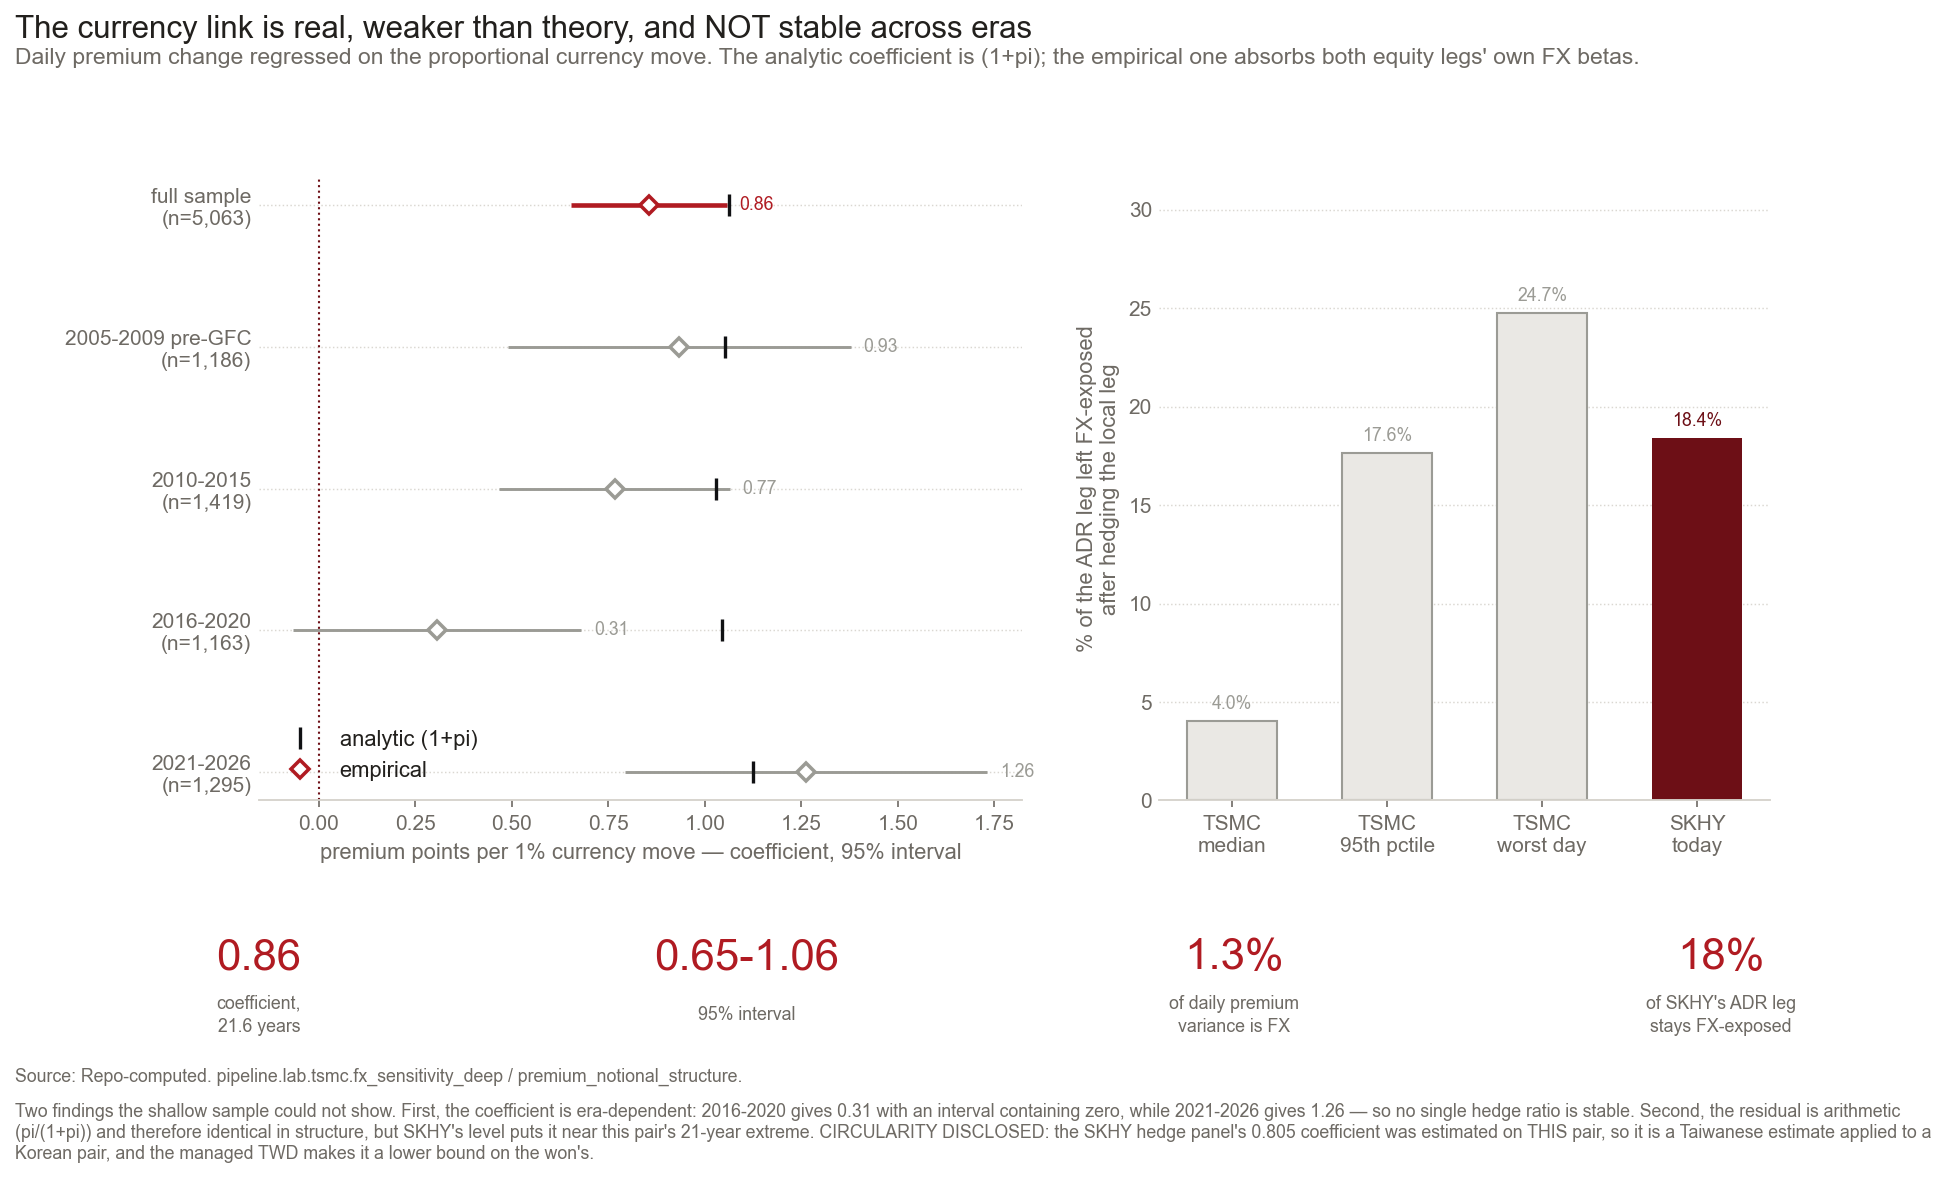

In [13]:
RS = LAB.premium_notional_structure(FRAME)
p = HedgeLegs.live("skhy").premium
fig, meta = figures.g27_fx_case(FX, RS, p / (1 + p))
fig;

**In plain terms**

- The gap is partly a currency bet, because a US share priced in dollars against a Korean share
  priced in won is a currency position whether you want one or not.
- Over 21 years the effect is real but smaller than the arithmetic suggests, and it changes from
  decade to decade — one five-year stretch shows almost no effect at all.
- And hedging the Korean leg does not make you currency-neutral: about 18% of the US leg stays
  exposed, which is near the widest this comparison pair has ever seen.

**Three things the shallow sample could not show.**

The coefficient is **0.856 (95% CI 0.653–1.058)** on 5,063 days, and FX explains **1.34%** of
daily premium variance. On 2,327 days the interval was 0.507–1.103 and comfortably contained
1.0; on the deep sample the pair's own analytic coefficient (1.062) sits just outside it. So
the mechanical link is real and partially offset — not "theory, unrejected".

It is **not stable across eras**. 2016–2020 gives 0.31 with an interval containing zero;
2021–2026 gives 1.26. No single hedge ratio is correct for all regimes, which is a caveat the
hedge menu's FX row now carries.

The **premium-as-currency-notional** structure is identical, because it is arithmetic:
hedging the local leg leaves `π/(1+π)` of the ADR leg exposed in any pair. What is not
arithmetic is the magnitude — TSMC's median residual is 4.0% and its 21-year maximum is
24.7%, while SKHY today sits at **18.4%**, above this pair's 95th percentile. The same hedge
is materially less complete on the traded pair than on the lab's.

**A circularity worth disclosing.** The FX coefficient shipped on the SKHY hedge menu was
estimated on *this* pair. It is a Taiwanese estimate applied to a Korean pair, and because
the TWD is a managed float, it is a lower bound on the won's sensitivity rather than a
like-for-like.

## 6. What the lab changes

| Sheet element | Direction | Why, by figure |
|---|---|---|
| **Risk-budget framing** | **HARDENED** | G26b. SKHY's realised week-one excursion exceeds the worst 252-day excursion in 21.6 years of a pair with a *softer* barrier. Sizing carries the risk; stops express intent. |
| **Short-ADR as the primary expression** | **PROMOTED** | G25. 56% of compressions and 74% of widenings ran through the ADR leg. The ADR is where both the convergence and the risk live. |
| **Financing conversation before the view** | **HARDENED, and now quantified** | G26. 55.5% / 41.8% / 16.4% by bracket. The bracket decides the trade; the signal only ranks entries within it. |
| **FX hedge row on the hedge menu** | **WEAKENED** | G27. Era-unstable (0.31 to 1.26), and its coefficient is borrowed from this comparator. Still worth doing; no longer quotable as one ratio. |
| **The ~80bp/month breakeven** | **UNTOUCHED** | The lab measures outcomes against the bracketed carry directly, so it neither confirms nor moves the breakeven arithmetic. |
| **The reflected-process claim itself** | **UNTOUCHED** | By construction. This pair's facility revolves; it cannot be evidence about a barrier it does not have. |
| **Half-life estimates** | **MOVED, mechanically** | The comparator's usable history went from 2,328 to 5,064 sessions, so the pooled constrained-class estimate is re-fitted on 2.2× the data. See notebook 04. |

---
**Informational only.** Not advice, not a recommendation, not a solicitation. Every number
here is a characterisation of a regime family measured on its *favourable* variant. Quoting a
fraction-beats-carry from a revolving facility as the probability an SKHY entry beats carry
substitutes the easier trade for the real one.